# 04 · Simulation storage — query terabytes, copy nothing
*OUF-Sim: manifest + spatial index + partial access, with a wrap-in-place mode that stores only an index over native files.*

Claims demonstrated: (i) a box read touches only overlapping chunks; (ii) **wrap-in-place** keeps ~13% of the re-encoded size by indexing the native files instead of copying them; (iii) storage is lossless — the stored field's P(k) matches the input to round-off.

In [1]:
%matplotlib inline
import os, sys, json, time, sqlite3, tempfile, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, healpy as hp
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrow, Rectangle, FancyBboxPatch
plt.rcParams.update({'figure.dpi':115,'font.size':10.5,'axes.titlesize':11.5,
    'axes.titleweight':'bold','axes.spines.top':False,'axes.spines.right':False,
    'figure.facecolor':'white'})
C0,C1,C2,C3,C4 = '#3a6ea5','#d1495b','#3c8d53','#edae49','#7d5ba6'
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT/'test'))
TMP = Path(tempfile.mkdtemp())
DATA_ROOT='/home/ravoux/Documents/Science/Cosmography/oneuniverse_data'
EBOSS=Path(DATA_ROOT)/'spectroscopic/eboss/qso/DR16Q_Superset_v3.fits'
DESI =Path(DATA_ROOT)/'spectroscopic/desi/dr1/qso/QSO_full.dat.fits'
HAVE_REAL = EBOSS.exists() and DESI.exists()
from oneuniverse.simulation.cosmology import CosmologySpec
COSMO = CosmologySpec(omega_m=0.31, omega_b=0.048, h=0.67, n_s=0.96, sigma8=0.81, t_cmb=2.7255)
def moll(ax, ra, dec, **kw):
    lon = np.radians(((np.asarray(ra)+180)%360)-180)
    ax.scatter(lon, np.radians(dec), **kw)
print('real eBOSS+DESI available:', HAVE_REAL)
def measure_pk(field, box, edges):
    '''Band-power P(k)=<|δ_k|²>V/N⁶ with Gaussian errors σ_P=P√(2/N_modes).'''
    n=field.shape[0]; dk=np.fft.rfftn(field)
    kf=np.fft.fftfreq(n,d=box/n)*2*np.pi; kz=np.fft.rfftfreq(n,d=box/n)*2*np.pi
    KX,KY,KZ=np.meshgrid(kf,kf,kz,indexing='ij'); km=np.sqrt(KX**2+KY**2+KZ**2).ravel()
    p=(np.abs(dk)**2*box**3/n**6).ravel(); idx=np.digitize(km,edges)
    k=[];P=[];E=[]
    for i in range(1,len(edges)):
        m=idx==i
        if m.sum()<2: continue
        k.append(km[m].mean()); P.append(p[m].mean()); E.append(p[m].mean()*np.sqrt(2.0/m.sum()))
    return np.array(k),np.array(P),np.array(E)

/home/ravoux/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


real eBOSS+DESI available: True


## Build a store, read a sub-box, see the pruning

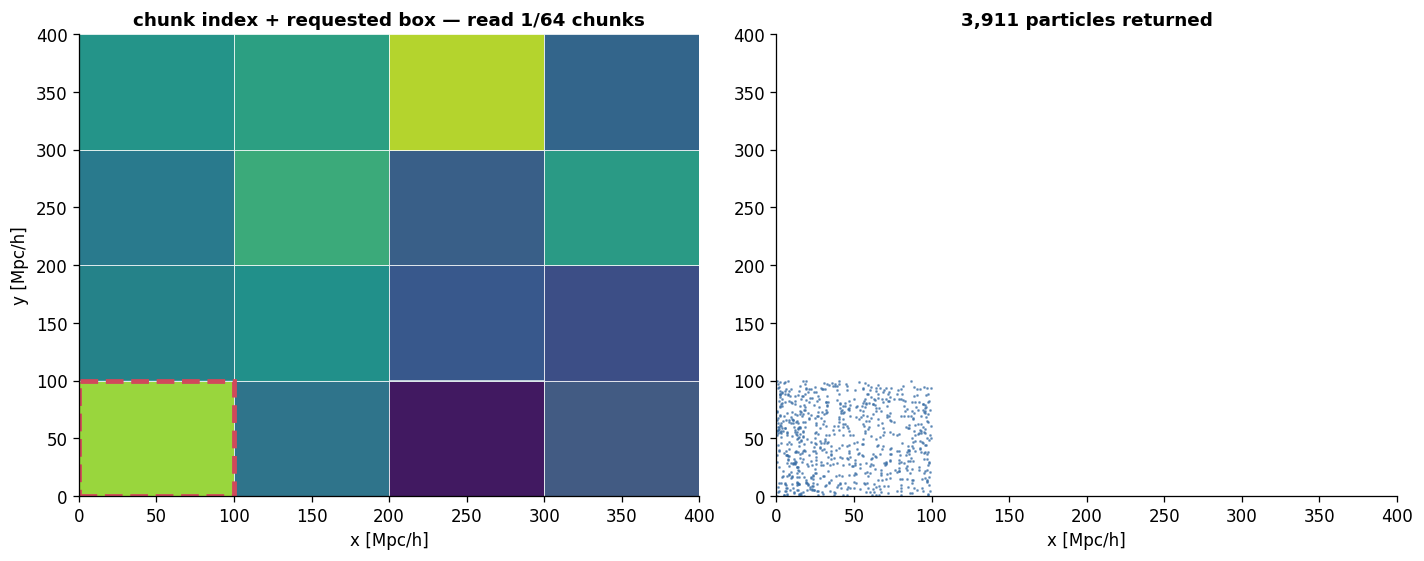

In [2]:
from oneuniverse.simulation.linear import generate_linear_sim
from oneuniverse.simulation.linear.pack import write_packed_native
from oneuniverse.simulation.packed.converter import PackedSimConverter
from oneuniverse.simulation.oufsim import SimStore
from oneuniverse.simulation.selectors import Cube
BOX,N=400.0,64
lin=generate_linear_sim(TMP/'lin',COSMO,box_size=BOX,n_grid=N,redshifts=(0.0,),seed=2,with_lightcone=False)
pk_native=write_packed_native(lin,TMP/'pk',particle_chunk_nside=4)
enc=PackedSimConverter().convert(pk_native,TMP/'enc',sim_name='d',projection='reencode')
ref=PackedSimConverter().convert(pk_native,TMP/'ref',sim_name='e',projection='reference')
store=SimStore(enc)
cube=Cube(0,BOX/4,0,BOX/4,0,BOX/4)
sub=store.read_box('snapshots',0.0,cube); st=store.last_read_stats
fig,ax=plt.subplots(1,2,figsize=(12.5,5))
import pyarrow.parquet as pq_
idx=pq_.read_table(Path(enc)/'snapshots'/'z0.000'/'_index.parquet').to_pandas()
norm=plt.Normalize(idx['n_rows'].min(),idx['n_rows'].max())
for _,r in idx.iterrows():
    hitc = not (r['xhi']<cube.xlo or r['xlo']>cube.xhi or r['yhi']<cube.ylo or r['ylo']>cube.yhi or r['zhi']<cube.zlo or r['zlo']>cube.zhi)
    ax[0].add_patch(Rectangle((r['xlo'],r['ylo']),r['xhi']-r['xlo'],r['yhi']-r['ylo'],
        fc=plt.cm.viridis(norm(r['n_rows'])),ec=(C1 if hitc else 'white'),lw=(2.4 if hitc else .5),alpha=.85))
ax[0].add_patch(Rectangle((cube.xlo,cube.ylo),cube.xhi-cube.xlo,cube.yhi-cube.ylo,fill=False,ec=C1,lw=3,ls='--'))
ax[0].set_xlim(0,BOX); ax[0].set_ylim(0,BOX); ax[0].set_xlabel('x [Mpc/h]'); ax[0].set_ylabel('y [Mpc/h]')
ax[0].set_title(f"chunk index + requested box — read {st['chunks_read']}/{st['chunks_total']} chunks")
ax[1].scatter(sub['x'][::5],sub['y'][::5],s=.6,c=C0,alpha=.6)
ax[1].set_xlim(0,BOX); ax[1].set_ylim(0,BOX); ax[1].set_title(f"{len(sub['x']):,} particles returned")
ax[1].set_xlabel('x [Mpc/h]'); plt.tight_layout(); plt.show()

## Wrap-in-place vs re-encode — and the byte-range index
The `reference` projection stores **no particle data** — only per-chunk `[row_start, row_stop)` ranges into the native, spatially-sorted file. Left: store sizes. Right: the actual byte-range map.

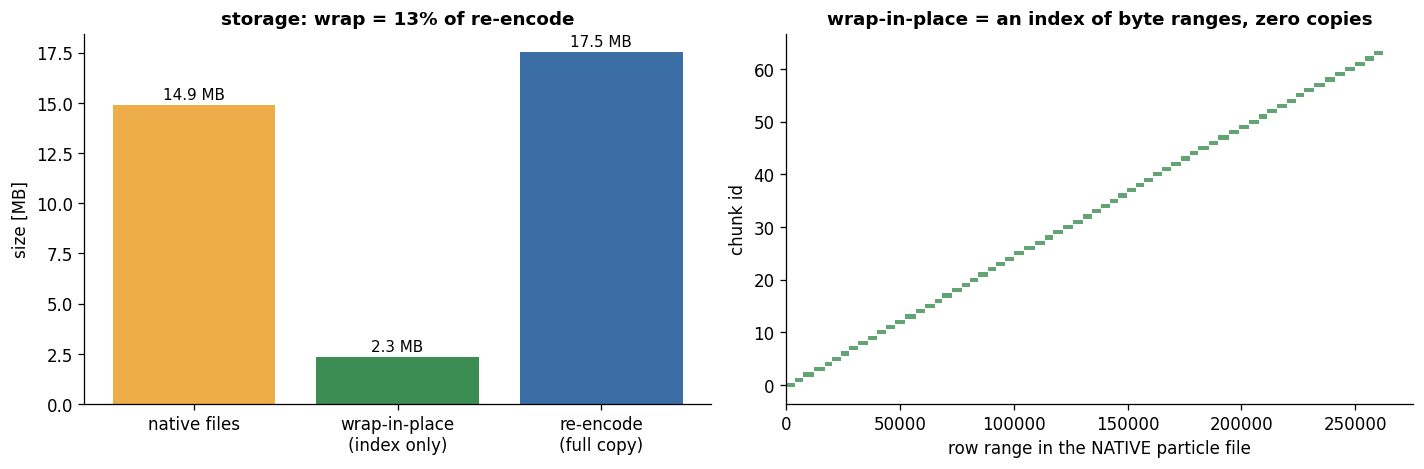

In [3]:
size=lambda p: sum(f.stat().st_size for f in Path(p).rglob('*') if f.is_file())/1e6
idx_ref=pq_.read_table(Path(ref)/'snapshots'/'z0.000'/'_index.parquet').to_pandas()
fig,ax=plt.subplots(1,2,figsize=(12.5,4.2))
vals=[size(pk_native),size(ref),size(enc)]
bars=ax[0].bar(['native files','wrap-in-place\n(index only)','re-encode\n(full copy)'],vals,color=[C3,C2,C0])
for b,v in zip(bars,vals): ax[0].text(b.get_x()+b.get_width()/2,v+.3,f'{v:.1f} MB',ha='center',fontsize=9.5)
ax[0].set_ylabel('size [MB]'); ax[0].set_title(f'storage: wrap = {100*vals[1]/vals[2]:.0f}% of re-encode')
y=np.arange(len(idx_ref))
ax[1].barh(y, idx_ref['row_stop']-idx_ref['row_start'], left=idx_ref['row_start'], height=.8, color=C2, alpha=.8)
ax[1].set_xlabel('row range in the NATIVE particle file'); ax[1].set_ylabel('chunk id')
ax[1].set_title('wrap-in-place = an index of byte ranges, zero copies')
plt.tight_layout(); plt.show()

## Lossless: P(k) of the stored field == input field

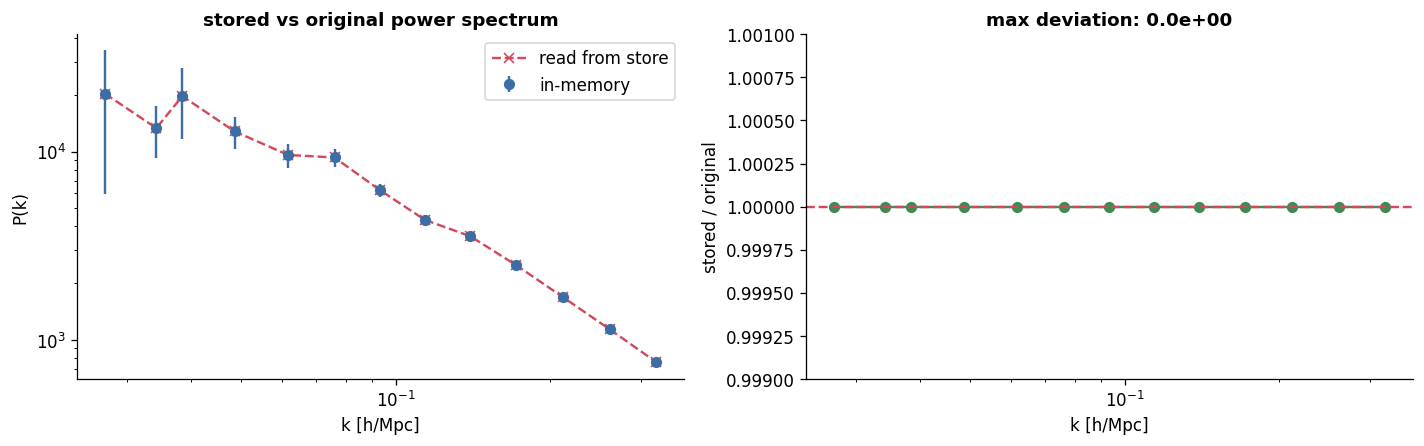

In [4]:
from oneuniverse.simulation.linear.gaussian_field import generate_density_field
orig=generate_density_field(COSMO,box_size=BOX,n_grid=N,z=0.0,seed=2)
stored,_=store.read_field_box(0.0,Cube(0,BOX,0,BOX,0,BOX))
kny=np.pi*N/BOX; edges=np.logspace(np.log10(2*np.pi/BOX*1.5),np.log10(.7*kny),14)
k1,P1,E1=measure_pk(orig,BOX,edges); k2,P2,_=measure_pk(np.asarray(stored),BOX,edges)
fig,ax=plt.subplots(1,2,figsize=(12.5,4))
ax[0].errorbar(k1,P1,yerr=E1,fmt='o',color=C0,label='in-memory'); ax[0].plot(k2,P2,'x--',color=C1,label='read from store')
ax[0].set_xscale('log'); ax[0].set_yscale('log'); ax[0].set_xlabel('k [h/Mpc]'); ax[0].set_ylabel('P(k)'); ax[0].legend()
ax[0].set_title('stored vs original power spectrum')
ax[1].plot(k1,P2/P1,'o-',color=C2); ax[1].axhline(1,color=C1,ls='--'); ax[1].set_xscale('log')
ax[1].set_ylim(.999,1.001); ax[1].set_xlabel('k [h/Mpc]'); ax[1].set_ylabel('stored / original')
ax[1].set_title(f'max deviation: {np.max(np.abs(P2/P1-1)):.1e}')
plt.tight_layout(); plt.show()

## It scales: index-only storage stays index-sized

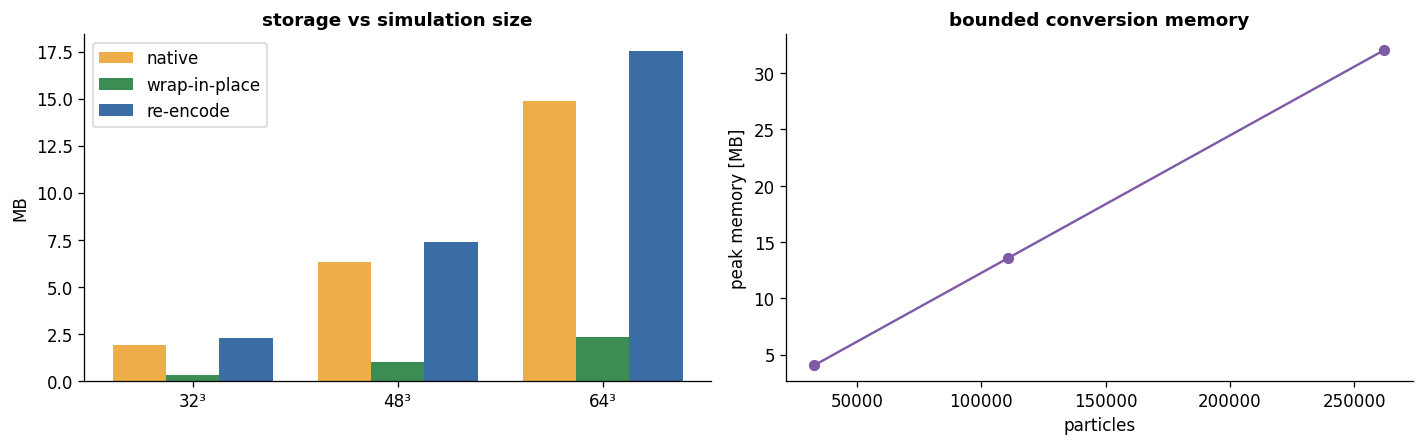

wrap fraction of re-encode: ['14%', '14%', '13%']


In [5]:
from oneuniverse.simulation.oufsim.scale_bench import sweep
rows=sweep(TMP/'sw',COSMO,grids=(32,48,64),box=BOX)
npart=[r['n_particles'] for r in rows]
fig,ax=plt.subplots(1,2,figsize=(12.5,4))
x=np.arange(len(rows)); w=.26
ax[0].bar(x-w,[r['native_mb'] for r in rows],w,label='native',color=C3)
ax[0].bar(x,[r['store_reference_mb'] for r in rows],w,label='wrap-in-place',color=C2)
ax[0].bar(x+w,[r['store_reencode_mb'] for r in rows],w,label='re-encode',color=C0)
ax[0].set_xticks(x); ax[0].set_xticklabels([f"{r['n_grid']}³" for r in rows])
ax[0].set_ylabel('MB'); ax[0].legend(); ax[0].set_title('storage vs simulation size')
ax[1].plot(npart,[r['convert_peak_mb'] for r in rows],'o-',color=C4)
ax[1].set_xlabel('particles'); ax[1].set_ylabel('peak memory [MB]')
ax[1].set_title('bounded conversion memory'); plt.tight_layout(); plt.show()
print('wrap fraction of re-encode:', ['%.0f%%'%(100*r['store_reference_mb']/r['store_reencode_mb']) for r in rows])

**What this showed.** A spatial chunk index that prunes box reads to the overlapping chunks; a wrap-in-place projection that is literally an index of byte ranges over the native files (~13% of a copy); bit-lossless field storage; and bounded conversion memory as the simulation grows. The *physics* stored here is a linear toy — the storage machinery is the real deliverable.